# Lab 07: Credit Card Fraud Detection

---
author: Trishla Nair
date: October 25, 2024
embed-resources: true
---

## Introduction

The goal is to generate a model to that will Identify Fradulent credit cards based off of 28 components and the Amount.

## Methods

In [11]:
# imports
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


# data generation and loading
from sklearn.datasets import make_regression
from sklearn.datasets import make_blobs
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors

# linear models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

# model tuning and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# model metrics
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score

### Data

In [2]:
# load data
fraud = pd.read_parquet("https://cs307.org/lab-07/data/fraud.parquet")
fraud_train, fraud_test = train_test_split(
    fraud,
    test_size=0.20,
    random_state=42,
    stratify=fraud["Fraud"],
)
fraud_train

,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,Amount,Fraud
57638,-0.514509,0.899378,1.627215,-0.142250,0.005250,-0.235422,0.482540,0.247403,-0.562327,-0.166813,...,-0.143290,-0.390205,0.030719,0.184779,-0.348711,0.073253,0.273217,0.107938,3.59,0
27686,-0.813568,-0.373893,1.152977,-0.449774,-3.868866,2.780636,3.654192,-0.672442,0.753230,-0.662803,...,-0.376783,-0.004239,0.074801,0.124238,-0.448493,0.861423,-0.093639,-0.711632,798.01,0
13321,-2.443142,3.258831,-0.791511,0.223548,0.007932,-1.263044,1.220214,-0.418068,1.860453,4.184883,...,-0.348587,0.531679,0.058990,0.371638,-0.207398,-0.505837,0.524542,-0.343895,1.79,0
28308,-0.397300,0.922104,1.224699,-0.334974,0.322603,-0.117372,0.534683,0.175550,-0.486404,-0.120147,...,-0.239303,-0.695001,-0.128231,-0.536463,-0.138971,0.107526,0.255644,0.100814,2.69,0
54252,1.994046,-0.367813,-0.462867,0.338661,-0.485326,-0.241576,-0.590987,0.089319,1.413224,-0.149292,...,-0.196388,-0.484457,0.421867,0.601393,-0.448014,-0.646256,0.027632,-0.027244,4.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49499,-0.033583,-0.487672,1.435406,-2.759369,-1.785638,0.402364,-2.306038,-2.287179,0.129717,-1.036412,...,-1.286823,0.824100,0.018890,0.000018,0.301618,0.081215,0.163422,0.252456,10.00,0
29250,-0.731245,1.151677,0.912393,-0.653540,0.700577,-0.461372,1.093273,-0.126254,-0.339171,-0.467356,...,-0.368185,-0.991854,-0.376461,-0.661608,0.554237,0.450650,0.076395,0.096252,6.99,0
31586,2.135923,-0.714182,-1.842502,-0.587267,0.090754,-0.465733,-0.024834,-0.328747,-0.659832,0.853241,...,-0.537267,-1.081138,0.196589,0.087797,-0.111583,0.479888,-0.082523,-0.053305,64.90,0
14898,-0.335632,0.939736,-2.961515,-1.224739,4.446891,2.352092,0.789725,0.609460,-0.746845,-1.580751,...,-0.002116,0.009686,-0.428325,0.536043,0.278736,0.680976,-0.069295,0.051891,0.76,0


The dataset consits of 29 features and 54276 rows.

In [3]:
# summary statistics
f = fraud_train.groupby(["Fraud"]).agg(['count', 'mean', 'std'])
f = f['Amount'].reset_index()
f

,Fraud,count,mean,std
0,0,53961,88.065104,241.451144
1,1,315,110.947016,254.978960


In [29]:
frauds = fraud_train[['Fraud', 'Amount']]
print(frauds['Amount'].median())
print(frauds['Amount'].max())

21.69
10199.44


<Axes: ylabel='Frequency'>

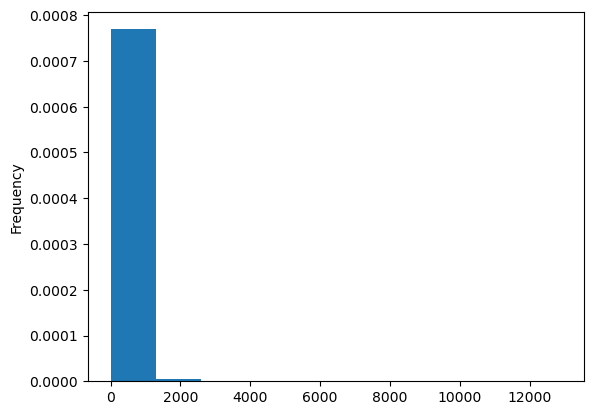

In [34]:
# visualizations
fraud['Amount'].plot.hist(bins = 10, density = True)

The Amount distribution appears to be skewed.

### Models

In [6]:
# process data for ML

# create X and y for train
X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]

# create X and y for test
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

In [35]:
# train models
# setup a pipeline
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=10000)),
    ]
)

# define parameter grid
param_grid = [
    {
        "model__penalty": ["l1", "l2"],
        "model__C": 1 / (10.0 ** np.arange(-4, 3)),
    }
]

# setup grid search and cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=["accuracy","recall"],
    refit = "accuracy",
)

# perform search
_ = grid_search.fit(X_train, y_train)

# print search results
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

# evaluate and print test metrics
test_score = grid_search.score(X_test, y_test)
print(f"Test accuracy: {test_score:.2f}")
print(f"Test recall: {test_score:.2f}")

Best parameters found: {'model__C': 10000.0, 'model__penalty': 'l2'}
Best cross-validated accuracy: 0.998323383842824
Test accuracy: 1.00
Test recall: 1.00


c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
35 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\pipeline.py", li

The model is split into testing and training based an 80-20 split. We then performed logistic regression with the best penalty and parameters from performing grid Search CV. We then examined the model's accuracy and recall on test data.

## Results

In [19]:
# report model metrics
from joblib import dump

dump(_, 'credit-fraud.joblib')

['credit-fraud.joblib']

The model reportedly has an accuracy and recall of 1.

## Discussion

The model's accuracy and recall score appear to be significantly high. The best penalty added to the model is an l2 penalty according to the Grid Search CV. I do think more points should be tested as the accuracy and recall are suspiciously high.

### Conclusion

Besides my concerns, the model performs well for predicting if a credit card is fraudulent or not.